# Chest X-ray pneumonia classifier: ResNet18 transfer learning

Same data as `04_chest_Xray_CNN.ipynb`, but the hand-built CNN is replaced by an **ImageNet-pretrained ResNet18**.

* The backbone is **frozen**: only the new final layer (`Linear(512, 1)` + sigmoid) is trained.
* Images are read as 3-channel RGB and normalised with the ImageNet mean/std the backbone was trained with.
* Training and validation use a reproducible, class-stratified 80/20 split of `train/`. Only validation drives early stopping; `test/` is evaluated after model selection.
* This is an image-level split: patient IDs are unavailable, so patient independence is unverified. Earlier versions used `test/` for model selection; its historical exposure cannot be undone by this fix. A fresh external set is needed for an untouched evaluation.
* Restart the kernel and run all cells to train a fresh model; existing checkpoints and metrics predate this fix.

At the end, the trained model is saved to `resnet18_pneumonia_model.pt`, with its metadata also written to `resnet18_pneumonia_model.json`.

## Model architecture

This model uses an ImageNet-pretrained **ResNet18** as a frozen feature extractor and trains a new binary classifier with **513 trainable parameters** (512 weights + 1 bias). Total parameters: **11,177,025**.

| Stage | Operation | Output per image |
|---|---|---|
| Input | RGB X-ray; scale to [0, 1], then ImageNet mean/std normalization | 3 × 224 × 224 |
| Stem | 7 × 7 convolution, 64 channels, stride 2; BatchNorm; ReLU | 64 × 112 × 112 |
| Pool | 3 × 3 max pooling, stride 2 | 64 × 56 × 56 |
| Residual stage 1 | 2 basic residual blocks, 64 channels | 64 × 56 × 56 |
| Residual stage 2 | 2 basic residual blocks, 128 channels; downsample | 128 × 28 × 28 |
| Residual stage 3 | 2 basic residual blocks, 256 channels; downsample | 256 × 14 × 14 |
| Residual stage 4 | 2 basic residual blocks, 512 channels; downsample | 512 × 7 × 7 |
| Global pooling | Adaptive average pooling and flatten | 512 |
| Trainable head | Linear(512, 1), followed by sigmoid | P(PNEUMONIA) |

Each basic block uses two 3 × 3 convolutions with BatchNorm and a residual skip connection. Downsampling blocks use a projected skip connection. Backbone weights **and BatchNorm running statistics stay frozen** during training. Only the final linear layer is optimized, using Adam and binary cross-entropy. The best epoch is selected using validation loss. Prediction is PNEUMONIA when its probability is **greater than 0.5**.


In [14]:
## On Google Colab, run the following lines before the imports:
!pip install pytorch-model-summary
!wget https://github.com/Bjarten/early-stopping-pytorch/raw/refs/heads/main/early_stopping_pytorch/early_stopping.py
!mv early_stopping.py pytorchtools.py


--2026-09-17 14:39:03--  https://github.com/Bjarten/early-stopping-pytorch/raw/refs/heads/main/early_stopping_pytorch/early_stopping.py
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Bjarten/early-stopping-pytorch/refs/heads/main/early_stopping_pytorch/early_stopping.py [following]
--2026-09-17 14:39:03--  https://raw.githubusercontent.com/Bjarten/early-stopping-pytorch/refs/heads/main/early_stopping_pytorch/early_stopping.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2416 (2.4K) [text/plain]
Saving to: ‘early_stopping.py’

early_stopping.py   100%[===================>]   2.36K  --.-KB/s  

In [15]:
## On Google Colab, run the following lines to download the sample images and datasets:

## Downloading 2 images:
!mkdir -p images
!wget https://github.com/sib-swiss/pytorch-practical-training/raw/refs/heads/master/images/NORMAL-1003233-0001.jpeg -O images/NORMAL-1003233-0001.jpeg
!wget https://github.com/sib-swiss/pytorch-practical-training/raw/refs/heads/master/images/BACTERIA-1008087-0001.jpeg -O images/BACTERIA-1008087-0001.jpeg

## Downloading and unzipping the resized datasets:
!wget 'https://sibcloud-my.sharepoint.com/:u:/g/personal/wandrille_duchemin_sib_swiss/ESDXFrlw6JJGiK8X7xG4aVEB06cxW82KyK_KWXMwccIVhw?download=1' -O chest_xray_224.zip
!wget 'https://sibcloud-my.sharepoint.com/:u:/g/personal/wandrille_duchemin_sib_swiss/EZLYtPxO4dlPr-2kysgQFYQBA0iLG3fEWnwrnlwvoHbZwg?download=1' -O chest_xray_64.zip

!mkdir -p data
!unzip -o chest_xray_224.zip
!mv -n chest_xray_224 data/

!unzip -o chest_xray_64.zip
!mv -n chest_xray_64 data/


Streaming output truncated to the last 5000 lines.
 extracting: chest_xray_64/train/NORMAL/NORMAL_377.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_858.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_1053.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_646.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_1344.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_1134.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_196.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_903.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_125.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_757.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_310.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_194.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_1204.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_683.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_466.jpeg  
 extracting: chest_xray_64/train/NORMAL/NORMAL_1045.jpeg  
 extracting: che

In [16]:
import json
import random
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision.transforms import v2
from torchvision.io import read_image, ImageReadMode
from torchvision.models import resnet18, ResNet18_Weights

from pytorchtools import EarlyStopping

# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

SEED = 0
torch.manual_seed(SEED)

Using cuda device


In [17]:
def train(dataloader, model, loss_fn, optimizer ,  echo = True , echo_batch = False):

    size = len(dataloader.dataset) # how many batches do we have
    model.train() #     Sets the module in training mode.

    for batch, (X,y) in enumerate(dataloader): # for each batch
        X = X.to(device) # send the data to the GPU or whatever device you use for training
        y = y.to(device) # send the data to the GPU or whatever device you use for training

        # Compute prediction error
        pred = model(X)              # prediction for the model -> forward pass
        loss = loss_fn(pred, y)      # loss function from these prediction

        # Backpropagation
        loss.backward()              # backward propagation
        #                            https://ml-cheatsheet.readthedocs.io/en/latest/backpropagation.html
        #                            https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html

        optimizer.step()
        optimizer.zero_grad()        # reset the gradients
                                     # https://stackoverflow.com/questions/48001598/why-do-we-need-to-call-zero-grad-in-pytorch

        if echo_batch:
            current =  (batch) * dataloader.batch_size +  len(X)
            print(f"Train loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

    if echo:
        print(f"Train loss: {loss.item():>7f}")

    # return the last batch loss
    return loss.item()

def valid(dataloader, model, loss_fn, echo = True):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() #     Sets the module in evaluation mode
    valid_loss = 0
    with torch.no_grad(): ## disables tracking of gradient: prevent accidental training + speeds up computation
        for X,y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            valid_loss += loss_fn(pred, y).item() * len(y)  ## accumulating the loss function over the batches

    valid_loss /= size

    if echo:
        print(f"Valid Error: {valid_loss:>8f}")
    ## return the average loss / batch
    return valid_loss

def get_model_accuracy(model, dataloader):
    # no_grad alone does not prevent BatchNorm running-statistic updates.
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            correct += ((pred.reshape(-1) > 0.5) == y.reshape(-1)).sum().item()
            total += y.numel()
    return correct / total


In [18]:
WEIGHTS = ResNet18_Weights.IMAGENET1K_V1
IMAGENET_MEAN = WEIGHTS.transforms().mean
IMAGENET_STD = WEIGHTS.transforms().std

# images are already 224x224: skip the weights' default Resize(256)+CenterCrop(224), which would cut the edges
rn_transform = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
read_image_rgb = lambda path: read_image(path, mode=ImageReadMode.RGB)

TRAIN_DIR = 'data/chest_xray_224/train'
TEST_DIR = 'data/chest_xray_224/test'
VALID_FRACTION = 0.2

full_train_dataset = torchvision.datasets.ImageFolder(
    TRAIN_DIR, loader=read_image_rgb, transform=rn_transform,
    target_transform=lambda x: torch.tensor([x], dtype=torch.float32))

# Split only the training folder, independently within each class.
# Local RNG keeps membership independent of model initialization and cell reruns.
rng = random.Random(SEED)
train_indices, valid_indices = [], []
for label in sorted(set(full_train_dataset.targets)):
    indices = [i for i, target in enumerate(full_train_dataset.targets) if target == label]
    rng.shuffle(indices)
    n_valid = round(len(indices) * VALID_FRACTION)
    valid_indices.extend(indices[:n_valid])
    train_indices.extend(indices[n_valid:])
train_indices.sort()
valid_indices.sort()
assert set(train_indices).isdisjoint(valid_indices)
assert sorted(train_indices + valid_indices) == list(range(len(full_train_dataset)))
train_dataset = Subset(full_train_dataset, train_indices)
valid_dataset = Subset(full_train_dataset, valid_indices)

batch_size = 64
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_dataloader = DataLoader(valid_dataset, shuffle=False, batch_size=batch_size)

print(full_train_dataset.class_to_idx, len(train_dataset), len(valid_dataset))
X, y = next(iter(train_dataloader))
X.shape, y.shape


{'NORMAL': 0, 'PNEUMONIA': 1} 4185 1047


(torch.Size([64, 3, 224, 224]), torch.Size([64, 1]))

In [19]:
class FrozenResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = resnet18(weights=WEIGHTS)
        for p in self.net.parameters():
            p.requires_grad = False
        # new modules are trainable by default
        self.net.fc = nn.Sequential(nn.Linear(self.net.fc.in_features, 1),
                                    nn.Sigmoid())

    def train(self, mode=True):
        super().train(mode)
        # requires_grad=False does not freeze BatchNorm: in train mode it would still
        # normalise with batch statistics and update its running averages
        for m in self.net.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
        return self

    def forward(self, x):
        return self.net(x)


model = FrozenResNet18().to(device).eval()
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"trainable parameters: {n_trainable} / {n_total}")

trainable parameters: 513 / 11177025


In [20]:
hparams = dict(optimizer = 'Adam',
               lr = 1e-3,
               batch_size = batch_size,
               patience = 10,
               max_epochs = 50,
               loss = 'BCELoss',
               seed = SEED)

loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.net.fc.parameters(), lr = hparams['lr'])

train_scores = []
valid_scores = []

CHECKPOINT = 'resnet18_checkpoint.pt'   # not 'checkpoint.pt', so notebook 04's checkpoint is kept
early_stopping = EarlyStopping(patience = hparams['patience'], verbose = False, path = CHECKPOINT)

## naive performance
print( "train accuracy:", get_model_accuracy(model, train_dataloader) )
print( "valid accuracy:", get_model_accuracy(model, valid_dataloader) )

train accuracy: 0.37108721624850655
valid accuracy: 0.3600764087870105


In [21]:
%%time

for t in range(hparams['max_epochs']):
    print('Epoch', len(train_scores) + 1)

    train_scores.append( train(train_dataloader,
                               model,
                               loss,
                               optimizer,
                               echo = True, echo_batch = False) )

    valid_scores.append( valid(valid_dataloader,
                               model,
                               loss,
                               echo = True) )

    early_stopping(valid_scores[-1], model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

epochs_run = len(train_scores)
best_epoch = int(np.argmin(valid_scores)) + 1

# load the checkpoint with the best model
model.load_state_dict(torch.load(CHECKPOINT))
print(f"ran {epochs_run} epochs, best epoch {best_epoch}")

Epoch 1
Train loss: 0.295062
Valid Error: 0.202996
Epoch 2
Train loss: 0.175824
Valid Error: 0.152701
Epoch 3
Train loss: 0.133589
Valid Error: 0.139257
Epoch 4
Train loss: 0.211444
Valid Error: 0.124140
Epoch 5
Train loss: 0.159266
Valid Error: 0.117737
Epoch 6
Train loss: 0.129972
Valid Error: 0.112875
Epoch 7
Train loss: 0.075538
Valid Error: 0.105736
Epoch 8
Train loss: 0.191852
Valid Error: 0.103176
Epoch 9
Train loss: 0.201511
Valid Error: 0.100941
Epoch 10
Train loss: 0.121162
Valid Error: 0.102038
EarlyStopping counter: 1 out of 10
Epoch 11
Train loss: 0.071321
Valid Error: 0.098497
Epoch 12
Train loss: 0.033778
Valid Error: 0.096780
Epoch 13
Train loss: 0.059227
Valid Error: 0.094931
Epoch 14
Train loss: 0.014531
Valid Error: 0.091551
Epoch 15
Train loss: 0.047744
Valid Error: 0.090462
Epoch 16
Train loss: 0.013939
Valid Error: 0.089999
Epoch 17
Train loss: 0.049363
Valid Error: 0.089109
Epoch 18
Train loss: 0.098096
Valid Error: 0.093280
EarlyStopping counter: 1 out of 10
Epo

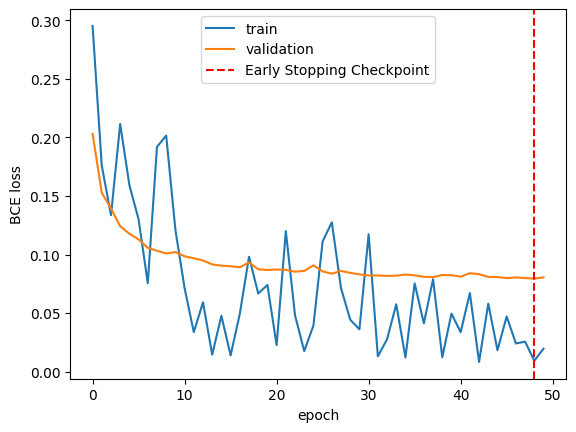

train accuracy: 0.9870967741935484
valid accuracy: 0.9713467048710601


In [22]:
plt.plot(train_scores, label = 'train')
plt.plot(valid_scores, label = 'validation')
plt.axvline(np.argmin(valid_scores), linestyle='--', color='r', label='Early Stopping Checkpoint')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('BCE loss')
plt.show()

train_accuracy = float(get_model_accuracy(model, train_dataloader))
valid_accuracy = float(get_model_accuracy(model, valid_dataloader))
print( "train accuracy:", train_accuracy )
print( "valid accuracy:", valid_accuracy )

In [23]:
# Final evaluation only: do not tune architecture, thresholds, or epochs on this score.
# Historical use of this folder for tuning means it is not a fresh external test.
test_dataset = torchvision.datasets.ImageFolder(
    TEST_DIR, loader=read_image_rgb, transform=rn_transform,
    target_transform=lambda x: torch.tensor([x], dtype=torch.float32))
assert test_dataset.class_to_idx == full_train_dataset.class_to_idx
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
test_accuracy = float(get_model_accuracy(model, test_dataloader))
print('test accuracy (historically exposed set):', test_accuracy)

MODEL_PATH = 'resnet18_pneumonia_model.pt'
META_PATH = 'resnet18_pneumonia_model.json'

metadata = {
    'model': {
        'architecture': 'resnet18',
        'pretrained_weights': 'ResNet18_Weights.IMAGENET1K_V1',
        'frozen_backbone': True,
        'head': 'fc = Sequential(Linear(512, 1), Sigmoid())',
        'output': 'probability of PNEUMONIA',
        'decision_threshold': 0.5,
        'trainable_parameters': n_trainable,
        'total_parameters': n_total,
        'state_dict_note': 'state dict of torchvision resnet18 with fc replaced by the head above (no wrapper prefix)',
    },
    'input': {
        'shape': [3, 224, 224],
        'color': 'RGB (read_image mode=ImageReadMode.RGB)',
        'scaling': 'ToDtype(float32, scale=True) -> [0, 1]',
        'normalize_mean': list(IMAGENET_MEAN),
        'normalize_std': list(IMAGENET_STD),
    },
    'data': {
        'class_to_idx': full_train_dataset.class_to_idx,
        'train_dir': TRAIN_DIR,
        'valid_source_dir': TRAIN_DIR,
        'test_dir': TEST_DIR,
        'split_seed': SEED,
        'validation_fraction': VALID_FRACTION,
        'split_method': 'class-stratified image-level split; patient independence unverified',
        'train_files': [str(Path(full_train_dataset.samples[i][0]).relative_to(TRAIN_DIR)) for i in train_indices],
        'valid_files': [str(Path(full_train_dataset.samples[i][0]).relative_to(TRAIN_DIR)) for i in valid_indices],
        'n_train': len(train_dataset),
        'n_valid': len(valid_dataset),
        'n_test': len(test_dataset),
        'note': 'Validation comes only from train/. Test is excluded from this training run but was used for tuning in earlier versions; not an untouched evaluation.',
    },
    'training': {
        **hparams,
        'epochs_run': epochs_run,
        'best_epoch': best_epoch,
        'best_valid_loss': float(min(valid_scores)),
        'train_losses': [float(x) for x in train_scores],
        'valid_losses': [float(x) for x in valid_scores],
    },
    'metrics': {
        'train_accuracy': train_accuracy,
        'valid_accuracy': valid_accuracy,
        'test_accuracy': test_accuracy,
    },
    'environment': {
        'torch': torch.__version__,
        'torchvision': torchvision.__version__,
        'device': device,
        'saved_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    },
}

torch.save({'model_state_dict': model.net.state_dict(),
            'train_accuracy': train_accuracy,
            'valid_accuracy': valid_accuracy,
        'test_accuracy': test_accuracy,
            'metadata': metadata},
           MODEL_PATH)
with open(META_PATH, 'w') as fh:
    json.dump(metadata, fh, indent=2)
print('saved', MODEL_PATH, 'and', META_PATH)

test accuracy (historically exposed set): 0.8878205128205128
saved resnet18_pneumonia_model.pt and resnet18_pneumonia_model.json


In [24]:
## reload check: a plain torchvision resnet18 + the same head must give the same accuracy
ckpt = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)

reloaded = resnet18()
reloaded.fc = nn.Sequential(nn.Linear(reloaded.fc.in_features, 1), nn.Sigmoid())
reloaded.load_state_dict(ckpt['model_state_dict'], strict=True)
reloaded = reloaded.to(device).eval()

reloaded_accuracy = float(get_model_accuracy(reloaded, valid_dataloader))
assert np.isclose(reloaded_accuracy, ckpt['valid_accuracy']), (reloaded_accuracy, ckpt['valid_accuracy'])
print('reloaded valid accuracy:', reloaded_accuracy)

reloaded valid accuracy: 0.9713467048710601


## Presentation panels A, B and D — existing saved model

**To use the existing model without retraining, run only the three code cells below.**
The first downloads the reviewed model and 624 test images from GitHub, defines `TEST_DIR`, and verifies the model checksum. The actual folder is `data/chest_xray_224/test`; `TEST_DIR` is its Python variable name.
You can also run this section after training/export above; skip the download cell when using a newly trained model.
The cells contain their own imports and do not require project helper scripts.
They evaluate the saved model without training or choosing a new threshold.

- **A:** Confusion matrix, with counts and percentages within each true class.
- **B:** ROC curve and AUC, computed from continuous pneumonia probabilities.
- **D:** Original X-rays and HiResCAM overlays for a true positive, true negative, false positive and false negative. Each example is closest to its category's median prediction confidence; filenames break ties.

The figure and individual panels are displayed and exported as PNG (300 dpi) and PDF in `resnet18_notebook_panels/`. Predictions and provenance are also saved.

**Interpretation:** This is an internal test set previously used during model development. Patient independence is unverified, and the training/validation split contains exact duplicates. HiResCAM shows positive contributions to the **predicted class's pre-sigmoid score**, independently normalized per image, at the final residual block (native resolution 7 × 7); it does not establish clinically correct localization. No threshold or model selection should be based on these test results.


In [ ]:
# Download the saved model and test images from GitHub; no training required.
# Git is preinstalled in Colab. Existing files are preserved.
import hashlib
from pathlib import Path
import shutil
import subprocess
import tempfile

download_model = Path("resnet18_pneumonia_model.pt")
download_metadata = Path("resnet18_pneumonia_model.json")
download_test = Path("data/chest_xray_224/test")
MODEL_PATH = str(download_model)
META_PATH = str(download_metadata)
TEST_DIR = str(download_test)
expected_model_sha256 = "7d4a4c30439293a8392f8abc246ea1e093bd5bc22e98d0bce263b1c134b8b409"
test_files = list(download_test.glob("*/*.jpeg"))
if not download_model.is_file() or not download_metadata.is_file() or len(test_files) != 624:
    with tempfile.TemporaryDirectory(prefix="resnet18-github-") as temporary:
        checkout = Path(temporary) / "repository"
        subprocess.run([
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "https://github.com/wxchew/xray_project.git", str(checkout)
        ], check=True)
        subprocess.run([
            "git", "-C", str(checkout), "sparse-checkout", "set",
            "data/chest_xray_224/test"
        ], check=True)
        for relative in (download_model, download_metadata):
            if not relative.exists():
                shutil.copy2(checkout / relative, relative)
        for source in (checkout / download_test).rglob("*"):
            if source.is_file():
                destination = download_test / source.relative_to(checkout / download_test)
                destination.parent.mkdir(parents=True, exist_ok=True)
                if not destination.exists():
                    shutil.copy2(source, destination)
assert hashlib.sha256(download_model.read_bytes()).hexdigest() == expected_model_sha256, (
    "Existing model differs from the reviewed model. Rename it before rerunning this download cell."
)
assert len(list(download_test.glob("*/*.jpeg"))) == 624, "Expected 624 test images."
print(f"Saved ResNet18 and 624 test images are ready. TEST_DIR = {TEST_DIR!r}")
print("Run the next two cells.")


In [ ]:
# Standalone evaluation: run with an existing exported model; no training required.
import csv
import hashlib
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.io import read_image, ImageReadMode
from torchvision.models import resnet18
from torchvision.transforms import v2
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

PANEL_MODEL = Path(globals().get("MODEL_PATH", "resnet18_pneumonia_model.pt"))
PANEL_DATA = Path(globals().get("TEST_DIR", "data/chest_xray_224/test"))
PANEL_OUTPUT = Path("resnet18_notebook_panels")
PANEL_THRESHOLD = 0.5
panel_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if not PANEL_MODEL.is_file() or not PANEL_DATA.is_dir():
    raise FileNotFoundError(
        "Upload resnet18_pneumonia_model.pt and provide data/chest_xray_224/test/ "
        "(NORMAL and PNEUMONIA subfolders), or run the setup/training cells first."
    )

panel_hash = hashlib.sha256(PANEL_MODEL.read_bytes()).hexdigest()
# TorchVersion may occur in the notebook's saved environment metadata.
with torch.serialization.safe_globals([torch.torch_version.TorchVersion]):
    panel_checkpoint = torch.load(PANEL_MODEL, map_location="cpu", weights_only=True)
panel_metadata = panel_checkpoint.get("metadata", {})
panel_net = resnet18(weights=None)  # no pretrained download; all weights come from the file
panel_net.fc = nn.Sequential(nn.Linear(512, 1), nn.Sigmoid())
panel_net.load_state_dict(panel_checkpoint["model_state_dict"], strict=True)
panel_net = panel_net.to(panel_device).eval()

panel_mean = [0.485, 0.456, 0.406]
panel_std = [0.229, 0.224, 0.225]
if panel_metadata:
    assert panel_metadata["data"]["class_to_idx"] == {"NORMAL": 0, "PNEUMONIA": 1}
    assert panel_metadata["input"]["shape"] == [3, 224, 224]
    assert np.allclose(panel_metadata["input"]["normalize_mean"], panel_mean)
    assert np.allclose(panel_metadata["input"]["normalize_std"], panel_std)
panel_dataset = datasets.ImageFolder(
    PANEL_DATA,
    loader=lambda path: read_image(path, mode=ImageReadMode.RGB),
    transform=v2.Compose([
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=panel_mean, std=panel_std),
    ]),
)
assert panel_dataset.class_to_idx == {"NORMAL": 0, "PNEUMONIA": 1}
panel_probabilities, panel_labels = [], []
with torch.inference_mode():
    for images, labels in DataLoader(panel_dataset, batch_size=64, shuffle=False):
        assert tuple(images.shape[1:]) == (3, 224, 224)
        panel_probabilities.extend(panel_net(images.to(panel_device)).flatten().cpu().tolist())
        panel_labels.extend(labels.tolist())
panel_probabilities = np.asarray(panel_probabilities)
panel_labels = np.asarray(panel_labels, dtype=int)
assert np.isfinite(panel_probabilities).all()
assert ((panel_probabilities >= 0) & (panel_probabilities <= 1)).all()
assert set(panel_labels) == {0, 1}, "ROC requires both classes."
panel_predictions = (panel_probabilities > PANEL_THRESHOLD).astype(int)
panel_matrix = confusion_matrix(panel_labels, panel_predictions, labels=[0, 1])
panel_accuracy = float(np.mean(panel_labels == panel_predictions))
panel_auc = float(roc_auc_score(panel_labels, panel_probabilities))
saved_accuracy = panel_checkpoint.get("test_accuracy")
if saved_accuracy is not None and not np.isclose(panel_accuracy, saved_accuracy, atol=1e-8):
    raise RuntimeError(f"Test accuracy {panel_accuracy} differs from saved {saved_accuracy}; check model/data.")
print(f"Device: {panel_device}; images: {len(panel_labels)}; "
      f"accuracy: {panel_accuracy:.4%}; ROC-AUC: {panel_auc:.4f}")
print("Confusion matrix [[TN, FP], [FN, TP]]:", panel_matrix.tolist())


In [ ]:
# Panel helpers and deterministic HiResCAM examples.
panel_names = ["NORMAL", "PNEUMONIA"]
panel_categories = {"TP": (1, 1), "TN": (0, 0), "FP": (0, 1), "FN": (1, 0)}

def panel_hirescam(image, predicted_class):
    captured = {}
    def capture(module, inputs, output):
        captured["activation"] = output
        output.retain_grad()
    handle = panel_net.layer4[-1].register_forward_hook(capture)
    try:
        panel_net.zero_grad(set_to_none=True)
        # Gradients are needed for explanation only; there is no optimizer or weight update.
        with torch.enable_grad():
            panel_net(image.unsqueeze(0).to(panel_device))
            activation = captured["activation"]
            logit = panel_net.fc[0](activation.mean(dim=(2, 3))).squeeze()
            score = logit if predicted_class == 1 else -logit
            score.backward()
        signed = (activation.detach() * activation.grad.detach()).sum(dim=1)[0]
        bias = panel_net.fc[0].bias.detach().squeeze() * (1 if predicted_class else -1)
        assert torch.allclose(signed.sum() + bias, score.detach(), atol=2e-5)
        heat = signed.relu()
        if heat.max() > 0:
            heat = heat / heat.max()
        heat = F.interpolate(heat[None, None], size=(224, 224),
                             mode="bilinear", align_corners=False)[0, 0]
        assert torch.isfinite(heat).all()
        return heat.cpu().numpy()
    finally:
        handle.remove()
        panel_net.zero_grad(set_to_none=True)

panel_examples = {}
for outcome, (truth, prediction) in panel_categories.items():
    candidates = np.flatnonzero((panel_labels == truth) & (panel_predictions == prediction))
    if not len(candidates):
        panel_examples[outcome] = None
        continue
    confidence = panel_probabilities if prediction else 1 - panel_probabilities
    median = np.median(confidence[candidates])
    index = min(candidates, key=lambda i: (
        abs(confidence[i] - median), panel_dataset.samples[i][0]))
    path = Path(panel_dataset.samples[index][0])
    tensor, _ = panel_dataset[index]
    heat = panel_hirescam(tensor, prediction)
    original = read_image(str(path), mode=ImageReadMode.RGB).permute(1, 2, 0).numpy() / 255.
    color = plt.get_cmap("inferno")(heat)[..., :3]
    alpha = 0.72 * heat[..., None]
    panel_examples[outcome] = {
        "original": original, "overlay": original * (1 - alpha) + color * alpha,
        "path": str(path), "truth": truth, "prediction": prediction,
        "probability": float(panel_probabilities[index]),
    }

def panel_draw_a(ax):
    ax.imshow(panel_matrix, cmap="Blues", vmin=0, vmax=panel_matrix.max())
    for row in range(2):
        for column in range(2):
            count = panel_matrix[row, column]
            percent = 100 * count / panel_matrix[row].sum()
            ax.text(column, row, f"{count}\n{percent:.1f}%", ha="center", va="center",
                    fontsize=13, color="white" if count > panel_matrix.max()/2 else "#172033")
    ax.set_xticks([0, 1], panel_names)
    ax.set_yticks([0, 1], panel_names)
    ax.set(xlabel="Predicted label", ylabel="True label",
           title="A  Confusion matrix (threshold = 0.5)")

def panel_draw_b(ax):
    fpr, tpr, _ = roc_curve(panel_labels, panel_probabilities)
    ax.plot(fpr, tpr, lw=2.5, label=f"ResNet18 (AUC = {panel_auc:.4f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="False-positive rate",
           ylabel="True-positive rate", title="B  ROC curve")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.2)

def panel_draw_d(fig, grid):
    for column, outcome in enumerate(panel_categories):
        example = panel_examples[outcome]
        for row in range(2):
            ax = fig.add_subplot(grid[row, column])
            ax.set_xticks([])
            ax.set_yticks([])
            if column == 0:
                ax.set_ylabel("Original" if row == 0 else "HiResCAM")
            if example is None:
                ax.text(.5, .5, f"{outcome}: no cases", ha="center", transform=ax.transAxes)
                continue
            ax.imshow(example["original"] if row == 0 else example["overlay"])
            if row == 0:
                ax.set_title(f"{outcome}\nTrue: {panel_names[example['truth']]}\n"
                             f"Pred: {panel_names[example['prediction']]}", fontsize=9)
            else:
                ax.set_xlabel(f"P(pneumonia) = {example['probability']:.4f}\n"
                              f"{Path(example['path']).name}", fontsize=8)

def panel_save(fig, name):
    for extension in ("png", "pdf"):
        fig.savefig(PANEL_OUTPUT / f"{name}.{extension}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

PANEL_OUTPUT.mkdir(exist_ok=True)
fig = plt.figure(figsize=(13, 12), constrained_layout=True)
layout = fig.add_gridspec(2, 2, height_ratios=[1, 1.25])
panel_draw_a(fig.add_subplot(layout[0, 0]))
panel_draw_b(fig.add_subplot(layout[0, 1]))
panel_draw_d(fig, layout[1, :].subgridspec(2, 4))
fig.suptitle(f"ResNet18 — internal test set (n = {len(panel_labels)})\n"
             "Previously used during model development\n"
             "D: median-confidence examples; predicted-class HiResCAM", fontsize=14)
panel_save(fig, "resnet18_panels_ABD")

for name, draw in [("panel_A_confusion_matrix", panel_draw_a), ("panel_B_roc", panel_draw_b)]:
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    draw(ax)
    panel_save(fig, name)
fig = plt.figure(figsize=(13, 7), constrained_layout=True)
panel_draw_d(fig, fig.add_gridspec(2, 4))
fig.suptitle("D  Median-confidence examples — predicted-class HiResCAM")
panel_save(fig, "panel_D_hirescam")

with (PANEL_OUTPUT / "predictions.csv").open("w", newline="") as stream:
    writer = csv.writer(stream)
    writer.writerow(["file", "true_label", "predicted_label", "pneumonia_probability"])
    for (path, _), truth, prediction, probability in zip(
            panel_dataset.samples, panel_labels, panel_predictions, panel_probabilities):
        writer.writerow([path, panel_names[truth], panel_names[prediction], float(probability)])
panel_results = {
    "checkpoint": str(PANEL_MODEL), "checkpoint_sha256": panel_hash,
    "data_directory": str(PANEL_DATA), "n_images": len(panel_labels),
    "threshold": PANEL_THRESHOLD, "decision_rule": "P(PNEUMONIA) > 0.5",
    "accuracy": panel_accuracy, "roc_auc": panel_auc,
    "confusion_matrix_rows_true_columns_predicted": panel_matrix.tolist(),
    "class_order": panel_names,
    "examples": {key: None if value is None else {
        k: v for k, v in value.items() if k not in ("original", "overlay")
    } for key, value in panel_examples.items()},
    "note": "Internal test set previously used during model development; "
            "patient independence unverified; training/validation duplicates known.",
}
(PANEL_OUTPUT / "results.json").write_text(json.dumps(panel_results, indent=2))
assert hashlib.sha256(PANEL_MODEL.read_bytes()).hexdigest() == panel_hash
print("Saved figures, predictions and provenance to", PANEL_OUTPUT.resolve())
